<a href="https://colab.research.google.com/github/nehavelmurugan14-oss/DAA-exp-1-/blob/main/DAA_EXPE_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cost Matrix

          A    B    C    D    E
    A  INF   10    8    9    7
    B   10  INF   10    5    6
    C    8   10  INF    8    9
    D    9    5    8  INF    6
    E    7    6    9    6  INF

Optimal Tour
A -> C -> D -> B -> E -> A

Minimum Cost = 34

Path Details
A -> C : 8
C -> D : 8
D -> B : 5
B -> E : 6
E -> A : 7


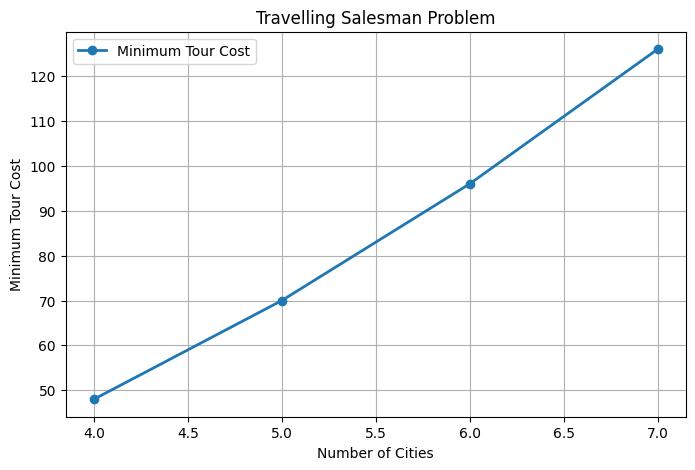

In [1]:
import matplotlib.pyplot as plt
from itertools import permutations

INF = float('inf')


# ---------------- Brute Force TSP ----------------
def tsp_brute_force(cost):

    n = len(cost)

    cities = list(range(1, n))

    best_cost = INF
    best_path = None

    for perm in permutations(cities):

        path = [0] + list(perm) + [0]

        total_cost = 0

        for i in range(n):
            total_cost += cost[path[i]][path[i + 1]]

        if total_cost < best_cost:
            best_cost = total_cost
            best_path = path

    return best_path, best_cost


# ---------------- Example ----------------
cost = [
    [INF,10,8,9,7],
    [10,INF,10,5,6],
    [8,10,INF,8,9],
    [9,5,8,INF,6],
    [7,6,9,6,INF]
]

cities = ['A','B','C','D','E']

path, minimum_cost = tsp_brute_force(cost)

print("Cost Matrix\n")

print("      ", end="")
for c in cities:
    print(f"{c:>5}", end="")
print()

for i in range(len(cost)):

    print(f"{cities[i]:>5}", end="")

    for value in cost[i]:

        if value == INF:
            print(f"{'INF':>5}", end="")
        else:
            print(f"{value:>5}", end="")

    print()

print("\nOptimal Tour")
print(" -> ".join(cities[i] for i in path))

print("\nMinimum Cost =", minimum_cost)

print("\nPath Details")

for i in range(len(path)-1):
    u = path[i]
    v = path[i+1]

    print(f"{cities[u]} -> {cities[v]} : {cost[u][v]}")


# ---------------- Performance Analysis ----------------

city_sizes = [4,5,6,7]

tour_cost = []

for n in city_sizes:

    matrix = [[INF]*n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[i][j] = (i + j + 3) * 2

    _, c = tsp_brute_force(matrix)

    tour_cost.append(c)


# ---------------- Graph ----------------

plt.figure(figsize=(8,5))

plt.plot(city_sizes,
         tour_cost,
         marker='o',
         linewidth=2,
         label="Minimum Tour Cost")

plt.title("Travelling Salesman Problem")
plt.xlabel("Number of Cities")
plt.ylabel("Minimum Tour Cost")
plt.grid(True)
plt.legend()

plt.show()